In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
from IPython.display import display
from vector_ptycho.utils import _to_numpy

device = "cuda" if torch.cuda.is_available() else "cpu"

from vector_ptycho.utils import *
from vector_ptycho.plotting_utils import *
from vector_ptycho.Neel_field_sim_utils import *
from vector_ptycho.reconstruction_utils import *

(3, 272, 272) (3, 272, 272)
Shape of normalisation arrays: (272, 272) (272, 272)


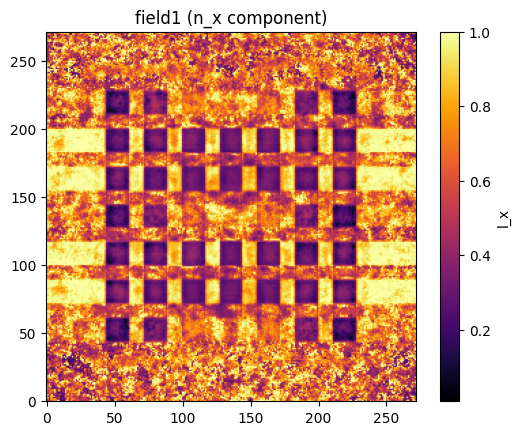

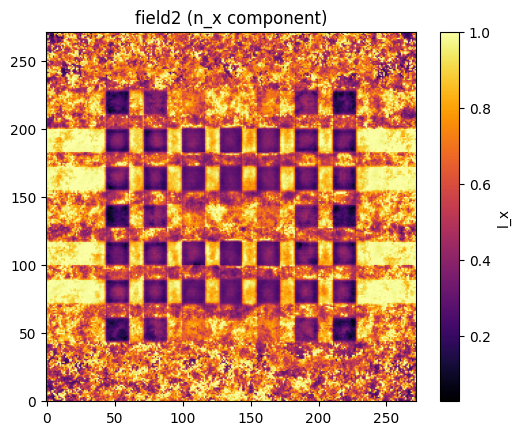

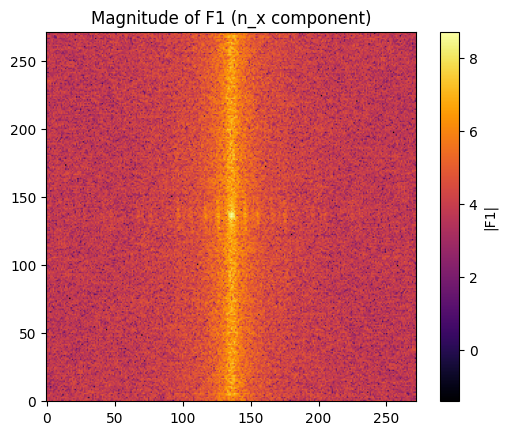

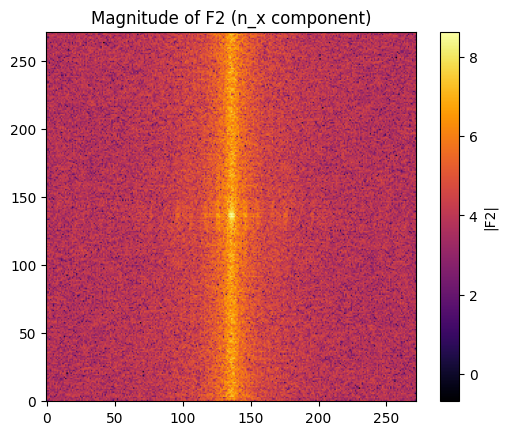

F1, F2 shapes: (3, 272, 272) (3, 272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (272, 272)
Mask shape: (2

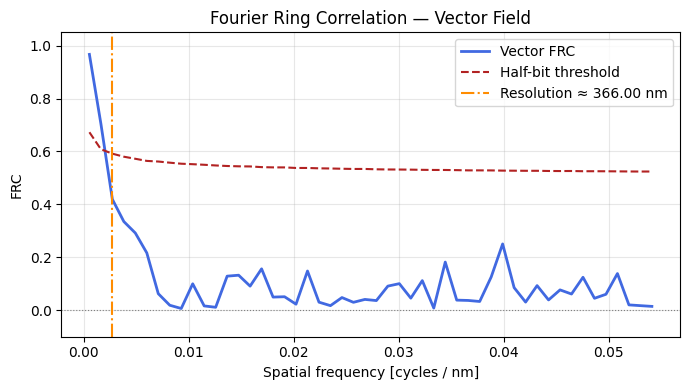

In [56]:

def vector_frc(field1: np.ndarray, field2: np.ndarray, pixel_size: float = 1.0):
    """
    Compute the Fourier Ring Correlation between two vector fields.

    Each field has shape (3, H, W)
    The vector dot product generalisation is used:

        FRC(q) = |sum_{q' in ring} F1(q') . F2*(q')| 
                 / sqrt(sum|F1|^2 * sum|F2|^2)

    where F1 . F2* = F1x*conj(F2x) + F1y*conj(F2y) + F1z*conj(F2z)

    Parameters
    ----------
    field1 : np.ndarray, shape (3, H, W)
        First vector field reconstruction.
    field2 : np.ndarray, shape (3, H, W)
        Second vector field reconstruction.
    pixel_size : float
        Physical size of each pixel (e.g. nm). Used to scale the frequency axis.
        Default 1.0 returns frequencies in units of cycles/pixel.

    Returns
    -------
    q_bins : np.ndarray, shape (n_bins,)
        Spatial frequency at the centre of each ring [cycles / pixel_size unit].
    frc : np.ndarray, shape (n_bins,)
        FRC value for each ring, in [0, 1].
    half_bit_threshold : np.ndarray, shape (n_bins,)
        Half-bit threshold as a function of ring occupancy.
    resolution : float
        Estimated resolution: 1 / q* where q* is the first crossing of the
        half-bit threshold. Units are the same as pixel_size.
    """
    field1 = np.array(_to_numpy(field1), copy=True)
    field2 = np.array(_to_numpy(field2), copy=True)

    C, H, W = field1.shape
    assert field2.shape == field1.shape, "Both fields must have the same shape"
    assert C == 3, "Last dimension must be 3 for [n_x, n_y, n_z]"

    def unwrap_director_field(lx, ly, lz):
        """
        Propagate a consistent gauge choice for a director field l ≡ -l
        using a flood-fill from a seed pixel.
        """
        shape = lx.shape
        field = np.stack([lx, ly, lz], axis=0)  # (3, ny, nx)
        fixed = np.zeros(shape, dtype=bool)
        result = field.copy()
        
        # Start from centre pixel
        seed = (shape[0]//2, shape[1]//2)
        fixed[seed] = True
        queue = [seed]
        
        while queue:
            i, j = queue.pop(0)
            ref = result[:, i, j]
            
            # Check 4-connected neighbours
            for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni, nj = i+di, j+dj
                if 0 <= ni < shape[0] and 0 <= nj < shape[1] and not fixed[ni, nj]:
                    neighbour = result[:, ni, nj]
                    # Flip neighbour if it points more anti-parallel than parallel
                    if np.dot(ref, neighbour) < 0:
                        result[:, ni, nj] = -neighbour
                    fixed[ni, nj] = True
                    queue.append((ni, nj))
        
        return result[0], result[1], result[2]

    field1[0], field1[1], field1[2] = unwrap_director_field(field1[0], field1[1], field1[2])
    field2[0], field2[1], field2[2] = unwrap_director_field(field2[0], field2[1], field2[2])

    # Normalise fields to unit length (director fields)
    norm1 = np.linalg.norm(field1, axis=0) + 1e-10
    norm2 = np.linalg.norm(field2, axis=0) + 1e-10
    print('Shape of normalisation arrays:', np.shape(norm1), np.shape(norm2))
    field1 /= norm1
    field2 /= norm2
    F1 = np.fft.fft2(field1, axes=(1, 2))
    F2 = np.fft.fft2(field2, axes=(1, 2))

    # Shift zero frequency to centre
    F1 = np.fft.fftshift(F1, axes=(1, 2))
    F2 = np.fft.fftshift(F2, axes=(1, 2))

    axis = 0
    plt.imshow(np.abs(field1[axis,:,:]), origin="lower", cmap="inferno")
    plt.title("field1 (n_x component)")
    plt.colorbar(label="l_x")
    plt.show()

    plt.imshow(np.abs(field2[axis,:,:]), origin="lower", cmap="inferno")
    plt.title("field2 (n_x component)")
    plt.colorbar(label="l_x")
    plt.show()

    plt.imshow(np.log(np.abs(F1[axis,:,:]) + 1e-10), origin="lower", cmap="inferno")
    plt.title("Magnitude of F1 (n_x component)")
    plt.colorbar(label="|F1|")
    plt.show()

    plt.imshow(np.log(np.abs(F2[axis,:,:]) + 1e-10), origin="lower", cmap="inferno")
    plt.title("Magnitude of F2 (n_x component)")
    plt.colorbar(label="|F2|")
    plt.show()

    print("F1, F2 shapes:", F1.shape, F2.shape)

    # --- Build radial frequency grid ---
    cy, cx = H // 2, W // 2
    fy = (np.arange(H) - cy) / (H * pixel_size)  # cycles per unit length
    fx = (np.arange(W) - cx) / (W * pixel_size)
    Fx, Fy = np.meshgrid(fx, fy)
    R = np.sqrt(Fx**2 + Fy**2)  # (H, W) radial frequency map

    # Maximum useful frequency: Nyquist
    q_nyquist = 0.5 / pixel_size
    #n_bins = min(H, W) // 2
    n_bins = 50
    # Bin edges and centres
    bin_edges = np.linspace(0, q_nyquist, n_bins + 1)
    q_bins = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    frc = np.zeros(n_bins)
    n_pixels = np.zeros(n_bins, dtype=int)

    for i in range(n_bins):
        mask = (R >= bin_edges[i]) & (R < bin_edges[i + 1])  # (H, W) bool

        #plt.imshow(mask.astype(float), origin="lower", cmap="gray")
        #plt.show()
        print("Mask shape:", mask.shape)
        n_pixels[i] = mask.sum()

        if n_pixels[i] == 0:
            continue

        # Extract pixels in this ring for all 3 components: shape (n_pix, 3)
        f1_ring = F1[:,mask]   # (n_pix, 3)
        f2_ring = F2[:,mask]   # (n_pix, 3)

        # Vector dot product: sum over pixels and components
        # numerator: |sum_pixels ( F1 . conj(F2) )|
        dot = np.sum(f1_ring * np.conj(f2_ring))          # scalar complex
        numerator = np.abs(dot)

        # Denominator: sqrt( sum|F1|^2 * sum|F2|^2 )
        # |F|^2 for a vector: sum over components
        power1 = np.sum(np.abs(f1_ring)**2)               # scalar real
        power2 = np.sum(np.abs(f2_ring)**2)               # scalar real
        denominator = np.sqrt(power1 * power2)

        if denominator > 0:
            frc[i] = numerator / denominator

    # --- Half-bit threshold ---
    # T(q) = (0.5 + 2.4142 / sqrt(n_q)) / (1 + 2.4142 / sqrt(n_q))
    with np.errstate(divide='ignore', invalid='ignore'):
        sqrt_n = np.sqrt(n_pixels.astype(float))
        half_bit_threshold = np.where(
            n_pixels > 0,
            (0.5 + 2.4142 / sqrt_n) / (1.0 + 2.4142 / sqrt_n),
            np.nan
        )

    # --- Find resolution: first crossing of half-bit threshold ---
    crossings = np.where(frc < half_bit_threshold)[0]
    if len(crossings) > 0:
        q_star = q_bins[crossings[0]]
        resolution = 1.0 / q_star if q_star > 0 else np.inf
    else:
        q_star = None
        resolution = np.inf
        print("Warning: FRC never crosses the half-bit threshold. "
              "Resolution may be limited by pixel size.")

    return q_bins, frc, half_bit_threshold, resolution


def plot_frc(q_bins, frc, half_bit_threshold, resolution, pixel_size_label="px"):
    """Plot the FRC curve with the half-bit threshold and resolution estimate."""
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(q_bins, frc, color="royalblue", lw=2, label="Vector FRC")
    ax.plot(q_bins, half_bit_threshold, color="firebrick", lw=1.5,
            linestyle="--", label="Half-bit threshold")
    ax.axhline(0, color="grey", lw=0.8, linestyle=":")

    if resolution < np.inf:
        ax.axvline(1.0 / resolution, color="darkorange", lw=1.5,
                   linestyle="-.", label=f"Resolution ≈ {resolution:.2f} {pixel_size_label}")

    ax.set_xlabel(f"Spatial frequency [cycles / {pixel_size_label}]")
    ax.set_ylabel("FRC")
    ax.set_title("Fourier Ring Correlation — Vector Field")
    ax.set_ylim(-0.1, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


if __name__ == "__main__":
    '''
    rng1 = np.random.default_rng(seed=42)
    rng2 = np.random.default_rng(seed=99)

    H, W = 256, 256
    pixel_size = 1.0  # nm (example)

    # Ground truth: a smooth director field (e.g. a skyrmion-like texture)
    y, x = np.mgrid[-H//2:H//2, -W//2:W//2].astype(float)
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    theta = np.pi * np.exp(-r**2 / (0.1 * H)**2)  # radial profile

    n_x = np.sin(theta) * np.cos(phi)
    n_y = np.sin(theta) * np.sin(phi)
    n_z = np.cos(theta)
    ground_truth = np.stack([n_x, n_y, n_z], axis=-1)  # (H, W, 3)

    # Simulate two independent noisy realisations
    noise_level = 0.00005
    field1 = ground_truth + rng1.normal(0, noise_level, ground_truth.shape)
    field2 = ground_truth + rng2.normal(0, noise_level, ground_truth.shape)
    '''
    pixel_size = 9.15  # nm (example)
    ckpt_rnd_seed0 = torch.load(r'.\Successfull fluence run 03_06_2026 RndSeed 0\fluence_1e12\recon_post_STXM_10.pt')
    field1 = _to_numpy(ckpt_rnd_seed0['l'])
    ckpt_rnd_seed5 = torch.load(r'.\Successfull fluence run 04_06_2026 RndSeed 5\fluence_1e12\recon_post_STXM_10.pt')
    field2 = _to_numpy(ckpt_rnd_seed5['l'])
    crop_size = 120
    field1 = field1[:, crop_size:-crop_size, crop_size:-crop_size]
    field2 = field2[:, crop_size:-crop_size, crop_size:-crop_size]
    print(field1.shape, field2.shape)
    # Renormalise to unit vectors (as you would after ptychographic reconstruction)
    field1 /= np.linalg.norm(field1, axis=-1, keepdims=True)
    field2 /= np.linalg.norm(field2, axis=-1, keepdims=True)

    q_bins, frc, half_bit, resolution = vector_frc(field1, field2, pixel_size=pixel_size)

    print(f"Estimated resolution: {resolution:.2f} nm")

    fig = plot_frc(q_bins, frc, half_bit, resolution, pixel_size_label="nm")
    plt.show()
